Connecting to Icechunk repository at s3://airborne-smce-prod-user-bucket/JOIN/icechunk-stores/VIIRS/VJ110A1F/V002/...
Opening virtual dataset from Icechunk...
Selecting CGF_NDSI_Snow_Cover data for 2018-10-01...
Found 11 spatial tiles for 2018-10-01.
Found Sinusoidal map coordinates in the dataset!
Generating global map and plotting tiles...
Plot saved to viirs_snow_cover_global_20181001.png


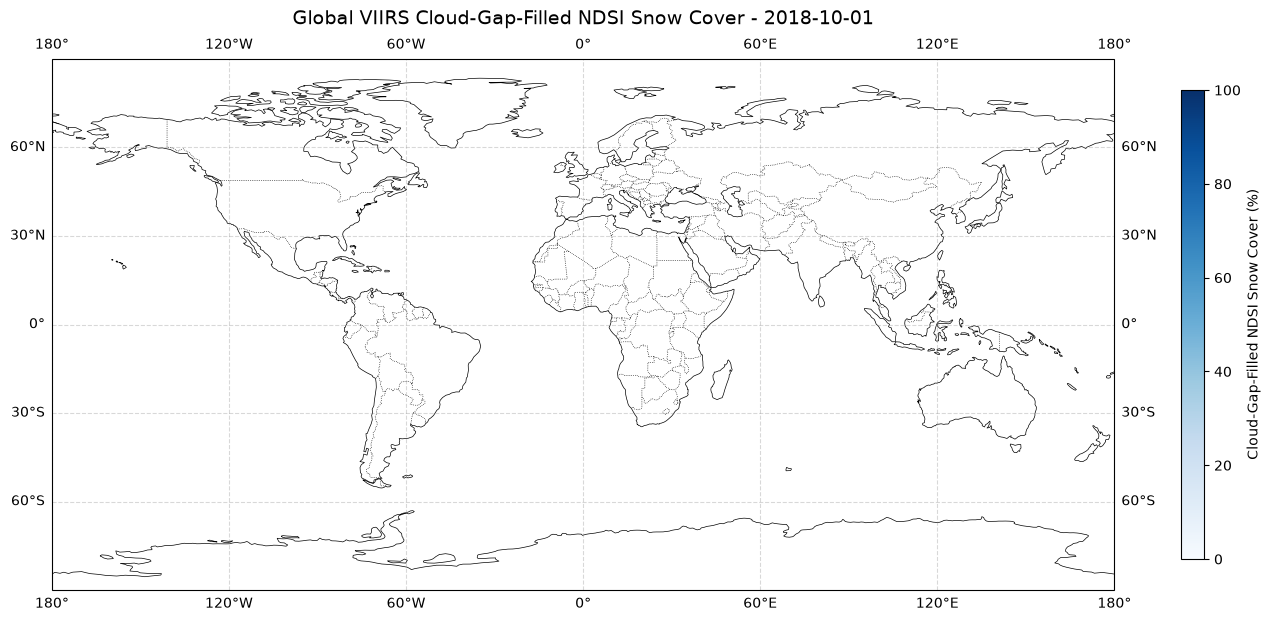

In [4]:
import os
import boto3
import icechunk
from icechunk.credentials import s3_credentials
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ==========================================
# 1. Configuration & Credentials
# ==========================================
bucket = "airborne-smce-prod-user-bucket"
icechunk_prefix = "JOIN/icechunk-stores/VIIRS/VJ110A1F/V002/"
source_base_url = f"s3://{bucket}"
aws_region = "us-west-2"

print(f"Connecting to Icechunk repository at s3://{bucket}/{icechunk_prefix}...")

boto_session = boto3.Session()
creds = boto_session.get_credentials()

static_creds = None
if creds:
    frozen_creds = creds.get_frozen_credentials()
    os.environ["AWS_ACCESS_KEY_ID"] = frozen_creds.access_key
    os.environ["AWS_SECRET_ACCESS_KEY"] = frozen_creds.secret_key
    if frozen_creds.token:
        os.environ["AWS_SESSION_TOKEN"] = frozen_creds.token
    os.environ["AWS_EC2_METADATA_DISABLED"] = "true"
    
    s3_static = s3_credentials(
        access_key_id=frozen_creds.access_key,
        secret_access_key=frozen_creds.secret_key,
        session_token=frozen_creds.token
    )
    static_creds = icechunk.credentials.Credentials.S3(s3_static)

# ==========================================
# 2. Configure Icechunk Access (Read-Only)
# ==========================================
storage = icechunk.s3_storage(region=aws_region, bucket=bucket, prefix=icechunk_prefix)
config = icechunk.RepositoryConfig.default()
container = icechunk.VirtualChunkContainer(
    name="viirs_archive",       
    url_prefix=f"{source_base_url}/",  
    store=icechunk.s3_store(region=aws_region)
)
config.set_virtual_chunk_container(container)

repo_kwargs = {"storage": storage, "config": config}
if static_creds:
    repo_kwargs["authorize_virtual_chunk_access"] = {f"{source_base_url}/": static_creds}

repo = icechunk.Repository.open(**repo_kwargs)
session = repo.readonly_session("main")

# ==========================================
# 3. Read and Select the Data
# ==========================================
print("Opening virtual dataset from Icechunk...")
ds = xr.open_zarr(session.store, zarr_format=3)

target_date = '2018-10-01'
print(f"Selecting CGF_NDSI_Snow_Cover data for {target_date}...")

# Mask for the specific date
date_mask = ds['time'].dt.strftime('%Y-%m-%d') == target_date
viirs_all_tiles = ds.isel(time=date_mask)

num_tiles = viirs_all_tiles.sizes['time']
print(f"Found {num_tiles} spatial tiles for {target_date}.")

if num_tiles == 0:
    print("No data found for that date!")
    exit()

# Try to identify the spatial dimension names (usually containing 'x' or 'y')
x_coord_name = next((dim for dim in viirs_all_tiles.dims if 'x' in str(dim).lower()), None)
y_coord_name = next((dim for dim in viirs_all_tiles.dims if 'y' in str(dim).lower()), None)

is_raw_index = True
if x_coord_name and y_coord_name:
    # Check the first tile to see if it has proper projection coordinates
    x_test_vals = viirs_all_tiles.isel(time=0)[x_coord_name].values
    if len(x_test_vals) > 0 and x_test_vals.max() > 2000:
        is_raw_index = False

if is_raw_index:
    print("\n🚨 WARNING: Dataset does not contain explicit X/Y projection coordinates.")
    print("Defaulting to raw array indices. All tiles will plot on top of each other incorrectly.")
    source_crs = ccrs.PlateCarree()
else:
    print("Found Sinusoidal map coordinates in the dataset!")
    globe = ccrs.Globe(semimajor_axis=6371007.181, semiminor_axis=6371007.181)
    source_crs = ccrs.Sinusoidal(globe=globe)


# ==========================================
# 4. Plot All Tiles on a Global Map
# ==========================================
print("Generating global map and plotting tiles...")

fig, ax = plt.subplots(
    figsize=(14, 7), 
    subplot_kw={'projection': ccrs.PlateCarree()}
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax.gridlines(draw_labels=True, alpha=0.3, color='gray', linestyle='--')
ax.set_global()  # Ensure we see the whole world

# Keep track of the last plot mesh so we can attach a colorbar to it
mesh = None

# Loop through all the tiles for this date
for i in range(num_tiles):
    tile = viirs_all_tiles.isel(time=i).squeeze()
    data_var = tile['CGF_NDSI_Snow_Cover'].values
    
    if is_raw_index:
        # Fallback if coordinates are missing
        x_vals = np.arange(data_var.shape[1])
        y_vals = np.arange(data_var.shape[0])
    else:
        # Extract the actual coordinates for this specific tile
        x_vals = tile[x_coord_name].values
        y_vals = tile[y_coord_name].values

    # pcolormesh is much faster and cleaner for looping than xarray's .plot()
    mesh = ax.pcolormesh(
        x_vals, y_vals, data_var,
        transform=source_crs,
        cmap='Blues',
        vmin=0, vmax=100
    )

# Add a single colorbar for all tiles
if mesh:
    cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, orientation='vertical', pad=0.05)
    cbar.set_label('Cloud-Gap-Filled NDSI Snow Cover (%)')

ax.set_title(f"Global VIIRS Cloud-Gap-Filled NDSI Snow Cover - {target_date}", fontsize=14, pad=10)

plt.tight_layout()

output_filename = f"viirs_snow_cover_global_{target_date.replace('-', '')}.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {output_filename}")

plt.show()